In [3]:
# Enable inline plotting for Jupyter notebooks
%matplotlib inline

# Import required libraries for visualization
import warnings
warnings.filterwarnings('ignore')

print("Notebook configured for interactive visualization")

Notebook configured for interactive visualization


In [4]:
conda install -c conda-forge jupyterlab_widgets notebook

Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done
Solving environment- done
done

# All requested packages already installed.


# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.

Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip install matplotlib numpy SimpleITK opencv-python


In [6]:
# Install required packages
!pip install antspyx SimpleITK matplotlib

In [7]:
!pip install torchio

In [8]:
conda install -c conda-forge opencv

Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done
Solving environment: done
done

## Package Plan ##

  environment location: /mnt/code/AKIB/ulf

  added / updated specs:
    - opencv


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    imath-3.2.2                |       hde8ca8f_0         157 KB  conda-forge
    libopencv-4.12.0           |qt6_py310hdb0ca46_607        31.1 MB  conda-forge
    opencv-4.12.0              |qt6_py310hec850f8_607          27 KB  conda-forge
    openexr-3.4.2              |       hff891e4_0         1.3 MB  conda-forge
    py-opencv-4.12.0           |qt6_py310h89973df_607         1.1 MB  conda-forge
    ------------------------------------------------------------
                                           Total:        33.7 MB

The following packages will be UPDATED:

  imath                                    3.2.1-hde8ca8f_0 --> 

In [9]:
conda install -c conda-forge ipywidgets=7.7.1


Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done
Solving environment: done
done

# All requested packages already installed.


# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.

Note: you may need to restart the kernel to use updated packages.


Helper functions

In [19]:
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, fixed, widgets
from IPython.display import display, clear_output
import numpy as np
import SimpleITK as sitk
import cv2

def explore_3D_array(arr: np.ndarray, cmap: str = 'gray'):
  """
  Given a 3D array with shape (Z,X,Y) This function will create an interactive
  widget to check out all the 2D arrays with shape (X,Y) inside the 3D array. 
  The purpose of this function to visual inspect the 2D arrays in the image. 

  Args:
    arr : 3D array with shape (Z,X,Y) that represents the volume of a MRI image
    cmap : Which color map use to plot the slices in matplotlib.pyplot
  """
  # Create the output widget
  output = widgets.Output()
  
  def view_slice(SLICE):
    with output:
      clear_output(wait=True)
      plt.figure(figsize=(7,7))
      plt.imshow(arr[SLICE, :, :], cmap=cmap)
      plt.title(f'Slice {SLICE}')
      plt.colorbar()
      plt.tight_layout()
  
  # Create the widget
  slider = widgets.IntSlider(min=0, max=arr.shape[0]-1, step=1, description='Slice:')
  
  # Link the widget to the function
  ui = interactive(view_slice, SLICE=slider)
  
  # Display the widget and output area
  display(ui, output)
  
  # Show initial slice
  view_slice(0)


def explore_3D_array_comparison(arr_before: np.ndarray, arr_after: np.ndarray, cmap: str = 'gray'):
  """
  Given two 3D arrays with shape (Z,X,Y) This function will create an interactive
  widget to check out all the 2D arrays with shape (X,Y) inside the 3D arrays.
  The purpose of this function to visual compare the 2D arrays after some transformation. 

  Args:
    arr_before : 3D array with shape (Z,X,Y) that represents the volume of a MRI image, before any transform
    arr_after : 3D array with shape (Z,X,Y) that represents the volume of a MRI image, after some transform    
    cmap : Which color map use to plot the slices in matplotlib.pyplot
  """
  assert arr_after.shape == arr_before.shape
  
  # Create the output widget
  output = widgets.Output()
  
  def view_comparison(SLICE):
    with output:
      clear_output(wait=True)
      fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
      
      # Left image (Before)
      ax1.imshow(arr_before[SLICE, :, :], cmap=cmap)
      ax1.axis('on')
      
      # Right image (After)
      ax2.imshow(arr_after[SLICE, :, :], cmap=cmap)
      ax2.axis('on')
      
      plt.tight_layout()
      plt.show()
  
  # Create the widget
  slider = widgets.IntSlider(min=0, max=arr_before.shape[0]-1, step=1, description='Slice:')
  
  # Link the widget to the function
  ui = interactive(view_comparison, SLICE=slider)
  
  # Display the widget and output area
  display(ui, output)
  
  # Show initial slice
  view_comparison(0)


def show_sitk_img_info(img: sitk.Image):
  """
  Given a sitk.Image instance prints the information about the MRI image contained.

  Args:
    img : instance of the sitk.Image to check out
  """
  pixel_type = img.GetPixelIDTypeAsString()
  origin = img.GetOrigin()
  dimensions = img.GetSize()
  spacing = img.GetSpacing()
  direction = img.GetDirection()

  info = {'Pixel Type' : pixel_type, 'Dimensions': dimensions, 'Spacing': spacing, 'Origin': origin,  'Direction' : direction}
  for k,v in info.items():
    print(f' {k} : {v}')


def add_suffix_to_filename(filename: str, suffix:str) -> str:
  """
  Takes a NIfTI filename and appends a suffix.

  Args:
      filename : NIfTI filename
      suffix : suffix to append

  Returns:
      str : filename after append the suffix
  """
  if filename.endswith('.nii'):
      result = filename.replace('.nii', f'_{suffix}.nii')
      return result
  elif filename.endswith('.nii.gz'):
      result = filename.replace('.nii.gz', f'_{suffix}.nii.gz')
      return result
  else:
      raise RuntimeError('filename with unknown extension')


def rescale_linear(array: np.ndarray, new_min: int, new_max: int):
  """Rescale an array linearly."""
  minimum, maximum = np.min(array), np.max(array)
  m = (new_max - new_min) / (maximum - minimum)
  b = new_min - m * minimum
  return m * array + b


def explore_3D_array_with_mask_contour(arr: np.ndarray, mask: np.ndarray, thickness: int = 1):
  """
  Given a 3D array with shape (Z,X,Y) This function will create an interactive
  widget to check out all the 2D arrays with shape (X,Y) inside the 3D array. The binary
  mask provided will be used to overlay contours of the region of interest over the 
  array. The purpose of this function is to visual inspect the region delimited by the mask.

  Args:
    arr : 3D array with shape (Z,X,Y) that represents the volume of a MRI image
    mask : binary mask to obtain the region of interest
  """
  assert arr.shape == mask.shape
  
  _arr = rescale_linear(arr,0,1)
  _mask = rescale_linear(mask,0,1)
  _mask = _mask.astype(np.uint8)
  
  # Create the output widget
  output = widgets.Output()
  
  def view_contour(SLICE):
    with output:
      clear_output(wait=True)
      plt.figure(figsize=(7,7))
      
      arr_rgb = cv2.cvtColor(_arr[SLICE, :, :], cv2.COLOR_GRAY2RGB)
      contours, _ = cv2.findContours(_mask[SLICE, :, :], cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
      
      arr_with_contours = cv2.drawContours(arr_rgb, contours, -1, (0,1,0), thickness)

      plt.imshow(arr_with_contours)
      plt.title(f'Slice {SLICE} with contours')
      plt.tight_layout()
      plt.show()
  
  # Create the widget
  slider = widgets.IntSlider(min=0, max=arr.shape[0]-1, step=1, description='Slice:')
  
  # Link the widget to the function
  ui = interactive(view_contour, SLICE=slider)
  
  # Display the widget and output area
  display(ui, output)
  
  # Show initial slice
  view_contour(0)

Data Loader


In [11]:
import os
import glob
import nibabel as nib
import numpy as np

# --- Configuration ---
BASE_DIR = '/mnt/Data/AKIB/Training data'
TARGET_SEQUENCE = 'T1' # Focusing on T1 for a start, as it is standard. You can loop through all three later.
NUM_SUBJECTS = 50

def load_image(filepath):
    """Loads a NIfTI file and returns the data array and NIfTI object."""
    try:
        img = nib.load(filepath)
        # Using .get_fdata() to get the image data as a floating-point array
        data = img.get_fdata()
        return data, img
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None, None

def organize_data_paths(base_dir, num_subjects, sequence):
    """Generates a list of dictionaries with paired file paths for all subjects."""
    data_list = []
    
    # Subject folders are named 1, 2, 3, ...
    for sub_id in range(1, num_subjects + 1):
        subject_dir = os.path.join(base_dir, str(sub_id))
        
        # Build file paths
        ulf_path = os.path.join(subject_dir, '64mT', f'{sub_id}_{sequence}.nii.gz')
        hf_path = os.path.join(subject_dir, '3T', f'{sub_id}_{sequence}.nii.gz')
        
        # Check if files exist before adding to the list
        if os.path.exists(ulf_path) and os.path.exists(hf_path):
            data_list.append({
                'subject_id': sub_id,
                'ulf_path': ulf_path,
                'hf_path': hf_path
            })
        else:
            print(f"Warning: Missing files for Subject {sub_id} ({sequence}). Skipping.")
            
    return data_list

# Get the list of file pairs
data_pairs = organize_data_paths(BASE_DIR, NUM_SUBJECTS, TARGET_SEQUENCE)
print(f"Found {len(data_pairs)} valid T1-weighted subject pairs.")
data_pairs[0]['ulf_path']

Found 50 valid T1-weighted subject pairs.


'/mnt/Data/AKIB/Training data/1/64mT/1_T1.nii.gz'

In [12]:
import os
from helpers import *

import ants
import SimpleITK as sitk

print(f'AntsPy version = {ants.__version__}')
print(f'SimpleITK version = {sitk.__version__}')

AntsPy version = 0.6.1
SimpleITK version = 2.5.2


In [ ]:
# Visualize the original 3D images before registration and preprocessing
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt

# Get the sample pair that we'll process
sample_pair = data_pairs[0]
print(f"Visualizing Subject {sample_pair['subject_id']} before registration...")

# Load the original images
ulf_sitk_orig = sitk.ReadImage(sample_pair['ulf_path'], sitk.sitkFloat32)
hf_sitk_orig = sitk.ReadImage(sample_pair['hf_path'], sitk.sitkFloat32)

# Convert to numpy arrays for visualization
ulf_orig = sitk.GetArrayFromImage(ulf_sitk_orig)
hf_orig = sitk.GetArrayFromImage(hf_sitk_orig)

print(f"Original ULF shape: {ulf_orig.shape}")
print(f"Original HF shape: {hf_orig.shape}")
print(f"ULF spacing: {ulf_sitk_orig.GetSpacing()}")
print(f"HF spacing: {hf_sitk_orig.GetSpacing()}")

# Visualize using the interactive slider function
print("\nInteractive visualization of ULF and HF images (before registration):")
# Show the ULF and HF images side by side with slider
if ulf_orig.shape[0] == hf_orig.shape[0]:
    explore_3D_array_comparison(ulf_orig, hf_orig, cmap='gray')
else:
    print("\nULF and HF have different numbers of slices, cannot directly compare side by side.")
    print(f"ULF has {ulf_orig.shape[0]} slices, HF has {hf_orig.shape[0]} slices.")

Visualizing Subject 1 before registration...
Original ULF shape: (160, 224, 224)
Original HF shape: (160, 224, 224)
ULF spacing: (1.0, 1.0, 1.0)
HF spacing: (1.0, 1.0, 1.0)

Interactive visualization of ULF and HF images (before registration):
Original ULF shape: (160, 224, 224)
Original HF shape: (160, 224, 224)
ULF spacing: (1.0, 1.0, 1.0)
HF spacing: (1.0, 1.0, 1.0)

Interactive visualization of ULF and HF images (before registration):


interactive(children=(IntSlider(value=79, description='SLICE', max=159), Output()), _dom_classes=('widget-inte…

Image registration

In [14]:
import SimpleITK as sitk

def preprocess_volumes(ulf_path, hf_path, target_spacing=(1.0, 1.0, 1.0)):
    # Load with SimpleITK
    ulf_sitk = sitk.ReadImage(ulf_path, sitk.sitkFloat32)
    hf_sitk = sitk.ReadImage(hf_path, sitk.sitkFloat32)

    # --- 1. Registration (Aligning ULF to HF) ---
    # Use a simple rigid registration to fine-tune alignment
    R = sitk.ImageRegistrationMethod()
    R.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
    R.SetOptimizerAsRegularStepGradientDescent(learningRate=2.0, numberOfIterations=100, minStep=0.01)
    R.SetInterpolator(sitk.sitkLinear)
    
    # Use the HF image as the fixed image and the ULF image as the moving image
    #### Place moving image to fixed image space
    
    initial_transform = sitk.CenteredTransformInitializer(
        hf_sitk, ulf_sitk, sitk.Euler3DTransform(), sitk.CenteredTransformInitializerFilter.GEOMETRY
    )
    
    # Set the initial transform before executing
    R.SetInitialTransform(initial_transform)
    
    # Execute registration with just the fixed and moving images
    final_transform = R.Execute(hf_sitk, ulf_sitk)
    
    # Apply the final transform to the ULF image
    resampled_ulf = sitk.Resample(
        ulf_sitk, hf_sitk, final_transform, sitk.sitkBSpline, 0.0, ulf_sitk.GetPixelID()
    )
    
    # --- 2. Resampling (Setting Isotropic Resolution) ---
    # Define a common reference space for isotropic 1mm resolution
    
    # Calculate new size to maintain physical size when changing spacing
    new_size = [int(sz * orig_sp / target_sp) for sz, orig_sp, target_sp in 
               zip(hf_sitk.GetSize(), hf_sitk.GetSpacing(), target_spacing)]
    
    # Create a reference image with the desired spacing
    reference_image = sitk.Image(new_size, hf_sitk.GetPixelID())
    reference_image.SetOrigin(hf_sitk.GetOrigin())
    reference_image.SetSpacing(target_spacing)
    reference_image.SetDirection(hf_sitk.GetDirection())
    
    # Resample both images to the new isotropic reference space
    resampled_hf = sitk.Resample(hf_sitk, reference_image)
    resampled_ulf = sitk.Resample(resampled_ulf, reference_image) # Use the aligned ULF

    # Convert back to numpy array for deep learning
    ulf_data_out = sitk.GetArrayFromImage(resampled_ulf)
    hf_data_out = sitk.GetArrayFromImage(resampled_hf)
    
    return ulf_data_out, hf_data_out

# --- Example Usage (Process one subject) ---
sample_pair = data_pairs[0]
print(f"\nProcessing Subject {sample_pair['subject_id']}...")

ulf_processed, hf_processed = preprocess_volumes(sample_pair['ulf_path'], sample_pair['hf_path'])
print(f"Processed ULF shape: {ulf_processed.shape}")
print(f"Processed HF shape: {hf_processed.shape}")

# Now, loop through all data pairs, save the processed NumPy files, 
# and move on to normalization and patching (next steps).


Processing Subject 1...
Processed ULF shape: (160, 224, 224)
Processed HF shape: (160, 224, 224)
Processed ULF shape: (160, 224, 224)
Processed HF shape: (160, 224, 224)


In [15]:
# Visualize the processed and registered images
print("Visualizing the processed images after registration")
print("ULF shape:", ulf_processed.shape)
print("HF shape:", hf_processed.shape)

ulf_unprocessed = sitk.GetArrayFromImage(sitk.ReadImage(sample_pair['ulf_path'], sitk.sitkFloat32))
hf_unprocessed = sitk.GetArrayFromImage(sitk.ReadImage(sample_pair['hf_path'], sitk.sitkFloat32))

# Use our comparison function to view both images side by side
explore_3D_array_comparison(ulf_unprocessed, ulf_processed, cmap='gray')
print("Interactive visualization launched. Use the slider to browse through slices.")

Visualizing the processed images after registration
ULF shape: (160, 224, 224)
HF shape: (160, 224, 224)


interactive(children=(IntSlider(value=79, description='SLICE', max=159), Output()), _dom_classes=('widget-inte…

Interactive visualization launched. Use the slider to browse through slices.


In [ ]:
# Use our comparison function to view both images side by side
explore_3D_array_comparison(hf_unprocessed, hf_processed, cmap='gray')
print("Interactive visualization launched. Use the slider to browse through slices.")

interactive(children=(IntSlider(value=79, description='SLICE', max=159), Output()), _dom_classes=('widget-inte…

Interactive visualization launched. Use the slider to browse through slices.


In [17]:
# Process and save multiple subjects
import os

def process_and_save_all_subjects(data_pairs, output_dir='/mnt/Data/AKIB/processed_data', max_subjects=50):
    """
    Process multiple subjects and save the registered and resampled data
    
    Args:
        data_pairs: List of dictionaries containing file paths for each subject
        output_dir: Directory to save processed data
        max_subjects: Maximum number of subjects to process (for testing)
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Process each subject
    for i, subject_data in enumerate(data_pairs[:max_subjects]):
        subject_id = subject_data['subject_id']
        print(f"Processing subject {subject_id} ({i+1}/{min(len(data_pairs), max_subjects)})...")
        
        try:
            # Process the volumes
            ulf_processed, hf_processed = preprocess_volumes(
                subject_data['ulf_path'], 
                subject_data['hf_path']
            )
            
            # Save as numpy arrays
            subject_dir = os.path.join(output_dir, f"subject_{subject_id}")
            os.makedirs(subject_dir, exist_ok=True)
            
            np.save(os.path.join(subject_dir, 'ulf_processed.npy'), ulf_processed)
            np.save(os.path.join(subject_dir, 'hf_processed.npy'), hf_processed)
            
            print(f"Subject {subject_id} processed and saved successfully!")
            
        except Exception as e:
            print(f"Error processing subject {subject_id}: {str(e)}")
    
    print("Processing complete!")

process_and_save_all_subjects(data_pairs, max_subjects=50)

Processing subject 1 (1/50)...
Subject 1 processed and saved successfully!
Processing subject 2 (2/50)...
Subject 1 processed and saved successfully!
Processing subject 2 (2/50)...
Subject 2 processed and saved successfully!
Processing subject 3 (3/50)...
Subject 2 processed and saved successfully!
Processing subject 3 (3/50)...
Subject 3 processed and saved successfully!
Processing subject 4 (4/50)...
Subject 3 processed and saved successfully!
Processing subject 4 (4/50)...
Subject 4 processed and saved successfully!
Processing subject 5 (5/50)...
Subject 4 processed and saved successfully!
Processing subject 5 (5/50)...
Subject 5 processed and saved successfully!
Processing subject 6 (6/50)...
Subject 5 processed and saved successfully!
Processing subject 6 (6/50)...
Subject 6 processed and saved successfully!
Processing subject 7 (7/50)...
Subject 6 processed and saved successfully!
Processing subject 7 (7/50)...
Subject 7 processed and saved successfully!
Processing subject 8 (8/5

Percentile (0,1) or z_score NORMALIZATION


In [18]:
# Data normalization and preparation for deep learning

def normalize_volume(volume, method='min_max'):
    """
    Normalize a 3D volume for neural network training
    
    Args:
        volume: 3D numpy array
        method: Normalization method ('min_max', 'z_score', or 'percentile')
        
    Returns:
        Normalized volume
    """
    if method == 'min_max':
        # Min-max scaling to [0,1]
        min_val = volume.min()
        max_val = volume.max()
        if max_val > min_val:
            return (volume - min_val) / (max_val - min_val)
        return volume - min_val  # Handle constant volumes
        
    elif method == 'z_score':
        # Z-score normalization (mean=0, std=1)
        mean_val = volume.mean()
        std_val = volume.std()
        if std_val > 0:
            return (volume - mean_val) / std_val
        return volume - mean_val  # Handle constant volumes
        
    elif method == 'percentile':
        # Percentile-based normalization (robust to outliers)
        p1 = np.percentile(volume, 1)
        p99 = np.percentile(volume, 99)
        if p99 > p1:
            vol_norm = (volume - p1) / (p99 - p1)
            # Clip values outside the percentile range
            return np.clip(vol_norm, 0, 1)
        return (volume - p1)  # Handle constant volumes
        
    else:
        raise ValueError(f"Unknown normalization method: {method}")

# Example usage
if 'ulf_processed' in locals() and 'hf_processed' in locals():
    # Normalize the processed volumes
    ulf_normalized = normalize_volume(ulf_processed, method='z_score')
    hf_normalized = normalize_volume(hf_processed, method='z_score')

    print("Normalization complete!")
    print(f"ULF normalized range: [{ulf_normalized.min():.4f}, {ulf_normalized.max():.4f}]")
    print(f"HF normalized range: [{hf_normalized.min():.4f}, {hf_normalized.max():.4f}]")
    
explore_3D_array_comparison(ulf_unprocessed, ulf_normalized, cmap='gray')
explore_3D_array_comparison(hf_unprocessed, hf_normalized, cmap='gray')

Normalization complete!
ULF normalized range: [-1.4882, 3.8893]
HF normalized range: [-0.7626, 3.8701]


interactive(children=(IntSlider(value=79, description='SLICE', max=159), Output()), _dom_classes=('widget-inte…

interactive(children=(IntSlider(value=79, description='SLICE', max=159), Output()), _dom_classes=('widget-inte…

In [23]:
# Load two NIfTI files (image + brain-extraction mask) and compare them
import os
import SimpleITK as sitk
import numpy as np

ulf_path = '/mnt/Data/AKIB/Training data/1/64mT/1_T2.nii.gz'
mask_path = '/mnt/Data/AKIB/Training data/1/64mT/1_T2_bet_mask.nii.gz'

print('ULF path:', ulf_path)
print('Mask path:', mask_path)

# Check files exist
if not os.path.exists(ulf_path):
    print(f"ERROR: ULF file not found: {ulf_path}")
else:
    print('ULF file found')

if not os.path.exists(mask_path):
    print(f"ERROR: Mask file not found: {mask_path}")
else:
    print('Mask file found')

# Read images
if os.path.exists(ulf_path) and os.path.exists(mask_path):
    ulf_img = sitk.ReadImage(ulf_path, sitk.sitkFloat32)
    mask_img = sitk.ReadImage(mask_path, sitk.sitkFloat32)

    ulf_arr = sitk.GetArrayFromImage(ulf_img)
    mask_arr = sitk.GetArrayFromImage(mask_img)

    print(f'ULF array shape: {ulf_arr.shape}, dtype: {ulf_arr.dtype}')
    print(f'Mask array shape: {mask_arr.shape}, dtype: {mask_arr.dtype}')

    # If shapes differ, warn (you can resample if needed)
    if ulf_arr.shape != mask_arr.shape:
        print('WARNING: Image and mask shapes differ. The comparison function expects identical shapes.')
        print('You may want to resample one image to the other''s grid before visualization.')
    else:
        # Use the comparison function defined earlier in the notebook
        print('\nLaunching interactive comparison (image vs mask)...')
        # The comparison function will show the image and the mask side-by-side
        explore_3D_array_comparison(ulf_arr, mask_arr, cmap='gray')
else:
    print('One or both files are missing; cannot run comparison.')


ULF path: /mnt/Data/AKIB/Training data/1/64mT/1_T2.nii.gz
Mask path: /mnt/Data/AKIB/Training data/1/64mT/1_T2_bet_mask.nii.gz
ULF file found
Mask file found
ULF array shape: (160, 224, 224), dtype: float32
Mask array shape: (160, 224, 224), dtype: float32

Launching interactive comparison (image vs mask)...


interactive(children=(IntSlider(value=0, description='Slice:', max=159), Output()), _dom_classes=('widget-inte…

Output()

FLAIR: /mnt/Data/AKIB/Training data/1/3T/1_FLAIR.nii.gz
Mask : /mnt/Data/AKIB/Training data/1/3T/1_FLAIR_bet_mask.nii.gz
Out  : /mnt/Data/AKIB/Training data/1/3T/1_FLAIR_skullstripped.nii.gz
FLAIR pixel type: 8-bit unsigned integer
Mask pixel type : 8-bit unsigned integer
FLAIR size: (224, 224, 160)
Mask size : (224, 224, 160)
Saved skull-stripped image to /mnt/Data/AKIB/Training data/1/3T/1_FLAIR_skullstripped.nii.gz
Skull-stripped array shape: (160, 224, 224) dtype: uint8

Previewing middle slice (array index): 80


interactive(children=(IntSlider(value=0, description='Slice:', max=159), Output()), _dom_classes=('widget-inte…

Output()

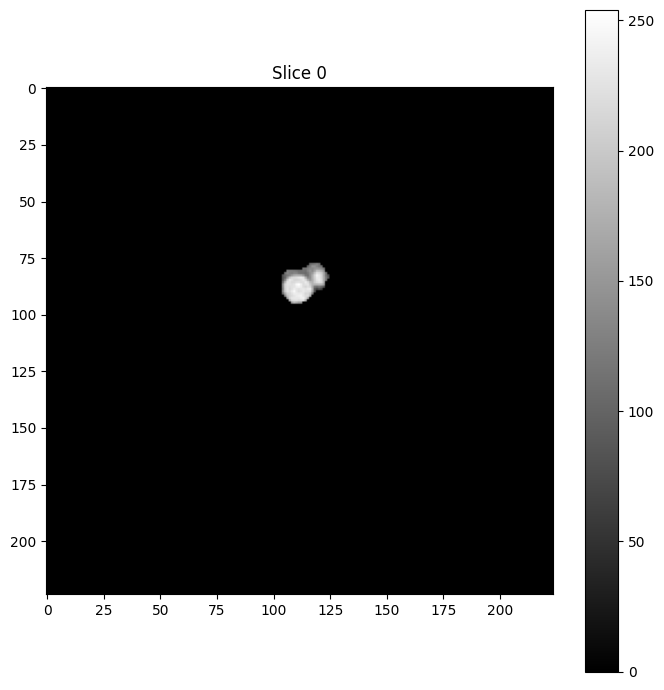

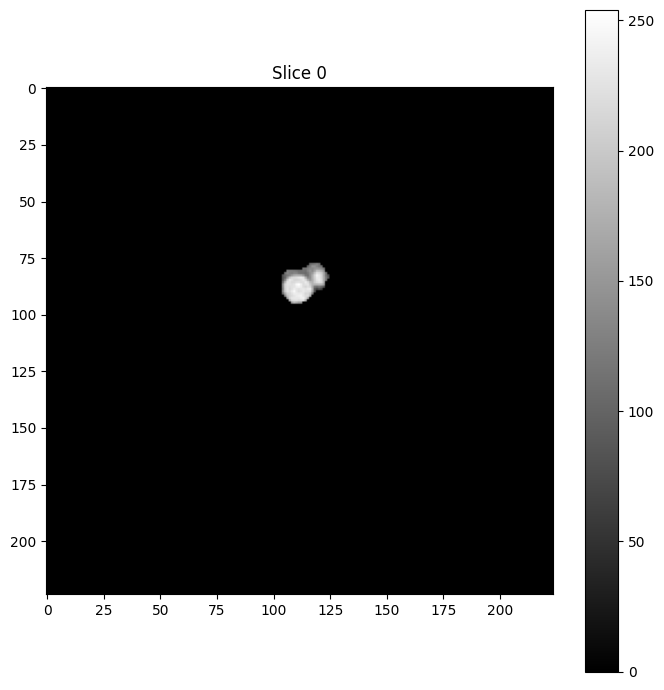

In [24]:
# Apply BET mask to create a skull-stripped image (FLAIR example)
import os
import SimpleITK as sitk
import numpy as np

# Paths (FLAIR + brain extraction mask)
flair_path = '/mnt/Data/AKIB/Training data/1/3T/1_FLAIR.nii.gz'
mask_path = '/mnt/Data/AKIB/Training data/1/3T/1_FLAIR_bet_mask.nii.gz'

# Output path (uses helper add_suffix_to_filename() from earlier cells)
try:
    out_path = add_suffix_to_filename(flair_path, 'skullstripped')
except Exception:
    # fallback if helper not loaded
    out_path = flair_path.replace('.nii.gz', '_skullstripped.nii.gz') if flair_path.endswith('.nii.gz') else flair_path.replace('.nii', '_skullstripped.nii')

print('FLAIR:', flair_path)
print('Mask :', mask_path)
print('Out  :', out_path)

if not os.path.exists(flair_path) or not os.path.exists(mask_path):
    raise FileNotFoundError('FLAIR or mask file not found. Check the paths above.')

# Read images
flair_img = sitk.ReadImage(flair_path)
mask_img = sitk.ReadImage(mask_path)

print('FLAIR pixel type:', flair_img.GetPixelIDTypeAsString())
print('Mask pixel type :', mask_img.GetPixelIDTypeAsString())
print('FLAIR size:', flair_img.GetSize())
print('Mask size :', mask_img.GetSize())

# Ensure mask is binary (0/1) and of integer type
# If mask is floating, threshold it; if integer but not 0/1, binarize >0
mask_bin = sitk.Cast(mask_img, sitk.sitkFloat32)
mask_bin = sitk.BinaryThreshold(mask_bin, lowerThreshold=0.5, upperThreshold=1e9, insideValue=1, outsideValue=0)
mask_bin = sitk.Cast(mask_bin, sitk.sitkUInt8)

# Make sure mask has same physical space metadata as the image. If mask was created in same space it's fine.
# If needed you could resample mask to the flair grid here; we assume same grid for BET masks.

# Apply mask: keep voxels where mask==1, set outside to 0
skullstripped_img = sitk.Mask(flair_img, mask_bin, outsideValue=0)

# Save skull-stripped image
sitk.WriteImage(skullstripped_img, out_path)
print('Saved skull-stripped image to', out_path)

# Convert to numpy array for preview
skull_arr = sitk.GetArrayFromImage(skullstripped_img)
print('Skull-stripped array shape:', skull_arr.shape, 'dtype:', skull_arr.dtype)

# Show a preview: middle slice
mid = skull_arr.shape[0] // 2
print('\nPreviewing middle slice (array index):', mid)
try:
    explore_3D_array(skull_arr, cmap='gray')
except Exception as e:
    # If interactive helper not available for some reason, show a static matplotlib image
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,6))
    plt.imshow(skull_arr[mid], cmap='gray')
    plt.title(f'Skull-stripped (slice {mid})')
    plt.axis('off')
    plt.show()


In [ ]:
# Compare original FLAIR and skull-stripped image slice-wise
import os
import SimpleITK as sitk
import numpy as np

orig_path = '/mnt/Data/AKIB/Training data/1/3T/1_FLAIR.nii.gz'
# Derived skull-stripped path (same convention used earlier)
try:
    skull_path = add_suffix_to_filename(orig_path, 'skullstripped')
except Exception:
    skull_path = orig_path.replace('.nii.gz', '_skullstripped.nii.gz') if orig_path.endswith('.nii.gz') else orig_path.replace('.nii', '_skullstripped.nii')

print('Original FLAIR:', orig_path)
print('Skull-stripped:', skull_path)

if not os.path.exists(orig_path):
    raise FileNotFoundError(f'Original file not found: {orig_path}')
if not os.path.exists(skull_path):
    raise FileNotFoundError(f'Skull-stripped file not found: {skull_path}')

# Read images
orig_img = sitk.ReadImage(orig_path)
skull_img = sitk.ReadImage(skull_path)

print('Original size:', orig_img.GetSize(), 'spacing:', orig_img.GetSpacing())
print('Skull size   :', skull_img.GetSize(), 'spacing:', skull_img.GetSpacing())

# If sizes or metadata differ, resample skull to original grid
def resample_to_reference(moving, reference, interpolator=sitk.sitkLinear, defaultValue=0):
    """Resample `moving` image to the grid/space of `reference`."""
    # Use reference as the target; keep reference origin/spacing/direction
    resampled = sitk.Resample(moving, reference, sitk.Transform(), interpolator, defaultValue, moving.GetPixelID())
    return resampled

if orig_img.GetSize() != skull_img.GetSize() or orig_img.GetDirection() != skull_img.GetDirection() or orig_img.GetOrigin() != skull_img.GetOrigin() or orig_img.GetSpacing() != skull_img.GetSpacing():
    print('Metadata mismatch detected: resampling skull-stripped image to original image grid...')
    skull_img = resample_to_reference(skull_img, orig_img, interpolator=sitk.sitkLinear, defaultValue=0)
    print('Resampling done. New skull size:', skull_img.GetSize(), 'spacing:', skull_img.GetSpacing())

# Convert to numpy arrays
orig_arr = sitk.GetArrayFromImage(orig_img)
skull_arr = sitk.GetArrayFromImage(skull_img)

print('Numpy shapes (z,x,y): original=', orig_arr.shape, ', skullstripped=', skull_arr.shape)
print('dtypes:', orig_arr.dtype, skull_arr.dtype)

# If dtypes differ, cast skull to same dtype for display
if orig_arr.dtype != skull_arr.dtype:
    skull_arr = skull_arr.astype(orig_arr.dtype)

# Launch the interactive slice-wise comparison
print('\nLaunching interactive slice-wise comparison (original vs skull-stripped)...')
explore_3D_array_comparison(orig_arr, skull_arr, cmap='gray')


Original FLAIR: /mnt/Data/AKIB/Training data/1/3T/1_FLAIR.nii.gz
Skull-stripped: /mnt/Data/AKIB/Training data/1/3T/1_FLAIR_skullstripped.nii.gz
Original size: (224, 224, 160) spacing: (1.0, 1.0, 1.0)
Skull size   : (224, 224, 160) spacing: (1.0, 1.0, 1.0)
Metadata mismatch detected: resampling skull-stripped image to original image grid...
Resampling done. New skull size: (224, 224, 160) spacing: (1.0, 1.0, 1.0)
Numpy shapes (z,x,y): original= (160, 224, 224) , skullstripped= (160, 224, 224)
dtypes: uint8 uint8

Launching interactive slice-wise comparison (original vs skull-stripped)...


interactive(children=(IntSlider(value=0, description='Slice:', max=159), Output()), _dom_classes=('widget-inte…

Output()

In [27]:
# Bulk skull-strip generator: apply available BET masks and save skull-stripped images
import os
import SimpleITK as sitk
import numpy as np

BASE_DIR = '/mnt/Data/AKIB/Training data'
scanners = ['64mT', '3T']
modalities = ['T1', 'T2', 'FLAIR']

# Helper: try both .nii.gz and .nii
def find_file_with_extensions(path_without_ext):
    for ext in ('.nii.gz', '.nii'):
        p = path_without_ext + ext
        if os.path.exists(p):
            return p
    return None

# Helper: add suffix preserving .nii(.gz)
def add_suffix(path, suffix):
    if path.endswith('.nii.gz'):
        return path.replace('.nii.gz', f'_{suffix}.nii.gz')
    elif path.endswith('.nii'):
        return path.replace('.nii', f'_{suffix}.nii')
    else:
        return path + f'_{suffix}'

# Resample mask to image grid using nearest neighbor (to preserve binary values)
def resample_mask_to_image(mask_img, ref_img):
    if (mask_img.GetSize() == ref_img.GetSize() and
        mask_img.GetOrigin() == ref_img.GetOrigin() and
        mask_img.GetSpacing() == ref_img.GetSpacing() and
        mask_img.GetDirection() == ref_img.GetDirection()):
        return mask_img
    resampled = sitk.Resample(mask_img, ref_img, sitk.Transform(), sitk.sitkNearestNeighbor, 0, mask_img.GetPixelID())
    return resampled

summary = {
    'processed': 0,
    'missing_image': [],
    'missing_mask': [],
    'errors': []
}

subjects = [d for d in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, d))]
subjects = sorted([s for s in subjects if s.isdigit() or True])  # keep all directories (many are numbered)

for subj in subjects:
    for scanner in scanners:
        scanner_dir = os.path.join(BASE_DIR, subj, scanner)
        if not os.path.isdir(scanner_dir):
            continue
        for mod in modalities:
            base_filepath = os.path.join(scanner_dir, f"{subj}_{mod}")
            img_path = find_file_with_extensions(base_filepath)
            if img_path is None:
                summary['missing_image'].append(os.path.join(scanner, f"{subj}_{mod}"))
                continue

            # Mask filename pattern: <id>_<mod>_bet_mask(.nii.gz/.nii)
            mask_base = os.path.join(scanner_dir, f"{subj}_{mod}_bet_mask")
            mask_path = find_file_with_extensions(mask_base)
            if mask_path is None:
                summary['missing_mask'].append(img_path)
                continue

            try:
                img = sitk.ReadImage(img_path)
                mask = sitk.ReadImage(mask_path)

                # Resample mask to image grid if needed
                mask_rs = resample_mask_to_image(mask, img)

                # Ensure mask binary
                mask_f = sitk.Cast(mask_rs, sitk.sitkFloat32)
                mask_bin = sitk.BinaryThreshold(mask_f, lowerThreshold=0.5, upperThreshold=1e9, insideValue=1, outsideValue=0)
                mask_bin = sitk.Cast(mask_bin, sitk.sitkUInt8)

                # Apply mask to produce skull-stripped image
                skull_img = sitk.Mask(img, mask_bin, outsideValue=0)

                out_path = add_suffix(img_path, 'skullstripped')
                sitk.WriteImage(skull_img, out_path)

                summary['processed'] += 1
                print(f'Processed: {img_path} -> {out_path}')

            except Exception as e:
                summary['errors'].append((img_path, str(e)))
                print(f'Error processing {img_path}: {e}')

# Print summary
print('\nBulk skull-strip summary:')
print('  Processed:', summary['processed'])
print('  Missing images (count):', len(summary['missing_image']))
print('  Missing masks (count):', len(summary['missing_mask']))
print('  Errors (count):', len(summary['errors']))

if summary['missing_image']:
    print('\nExamples of missing images:')
    for i, m in enumerate(summary['missing_image'][:10], 1):
        print(f'  {i}. {m}')

if summary['missing_mask']:
    print('\nExamples of missing masks:')
    for i, m in enumerate(summary['missing_mask'][:10], 1):
        print(f'  {i}. {m}')

if summary['errors']:
    print('\nExample errors:')
    for i, (p, msg) in enumerate(summary['errors'][:10], 1):
        print(f'  {i}. {p} -> {msg}')

print('\nDone.')


Processed: /mnt/Data/AKIB/Training data/1/64mT/1_T1.nii.gz -> /mnt/Data/AKIB/Training data/1/64mT/1_T1_skullstripped.nii.gz
Processed: /mnt/Data/AKIB/Training data/1/64mT/1_T2.nii.gz -> /mnt/Data/AKIB/Training data/1/64mT/1_T2_skullstripped.nii.gz
Processed: /mnt/Data/AKIB/Training data/1/64mT/1_FLAIR.nii.gz -> /mnt/Data/AKIB/Training data/1/64mT/1_FLAIR_skullstripped.nii.gz
Processed: /mnt/Data/AKIB/Training data/1/3T/1_T1.nii.gz -> /mnt/Data/AKIB/Training data/1/3T/1_T1_skullstripped.nii.gz
Processed: /mnt/Data/AKIB/Training data/1/3T/1_T2.nii.gz -> /mnt/Data/AKIB/Training data/1/3T/1_T2_skullstripped.nii.gz
Processed: /mnt/Data/AKIB/Training data/1/3T/1_FLAIR.nii.gz -> /mnt/Data/AKIB/Training data/1/3T/1_FLAIR_skullstripped.nii.gz
Processed: /mnt/Data/AKIB/Training data/1/3T/1_T1.nii.gz -> /mnt/Data/AKIB/Training data/1/3T/1_T1_skullstripped.nii.gz
Processed: /mnt/Data/AKIB/Training data/1/3T/1_T2.nii.gz -> /mnt/Data/AKIB/Training data/1/3T/1_T2_skullstripped.nii.gz
Processed: /mnt/